# 타이타닉 생존 데이터 분석

인터넷에서 타이타닉 승객 데이터를 내려받아 데이터 클렌징을 수행하고, `pandas`와 `matplotlib`로 생존 요인을 여러 관점에서 분석합니다.

분석 순서: 데이터 수집 → 데이터 구조 확인 → 결측치·중복 처리 → 파생 변수 생성 → 탐색적 분석 → 시각화 → 성별 생존율 비교

In [1]:
from pathlib import Path
import platform
import requests
import pandas as pd
import matplotlib.pyplot as plt

# 한글 그래프 표시를 위한 운영체제별 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

## 1. 데이터 수집

공개 GitHub 저장소의 CSV를 사용합니다. 한 번 내려받은 데이터는 `titanic.csv`로 저장하고, 인터넷 연결이 없으면 로컬 파일을 사용합니다.

In [2]:
DATA_URL = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
DATA_PATH = Path('titanic.csv')

try:
    response = requests.get(DATA_URL, timeout=20)
    response.raise_for_status()
    DATA_PATH.write_bytes(response.content)
    print(f'인터넷에서 데이터를 내려받았습니다: {DATA_PATH.resolve()}')
except requests.RequestException as error:
    if not DATA_PATH.exists():
        raise RuntimeError('인터넷 다운로드에 실패했고 로컬 캐시도 없습니다.') from error
    print(f'인터넷 다운로드 실패로 로컬 캐시를 사용합니다: {DATA_PATH.resolve()}')

raw_df = pd.read_csv(DATA_PATH)
print(f'데이터 크기: {raw_df.shape[0]:,}행 x {raw_df.shape[1]}열')
raw_df.head()

인터넷에서 데이터를 내려받았습니다: C:\work\titanic.csv
데이터 크기: 891행 x 12열


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. 데이터 구조 확인

먼저 자료형, 결측치, 중복 행, 기초 통계량을 확인합니다. 이 단계의 결과를 바탕으로 정제 규칙을 결정합니다.

In [3]:
print('열별 자료형')
display(raw_df.dtypes.to_frame('dtype'))

print('열별 결측치 개수')
display(raw_df.isna().sum().to_frame('missing_count'))

print(f'중복 행 수: {raw_df.duplicated().sum()}')
display(raw_df.describe(include='all').T)

열별 자료형


,dtype
PassengerId,int64
Survived,int64
Pclass,int64
Name,str
Sex,str
Age,float64
SibSp,int64
Parch,int64
Ticket,str
Fare,float64


열별 결측치 개수


,missing_count
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


중복 행 수: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


## 3. 데이터 클렌징과 파생 변수 생성

- 완전히 같은 중복 행을 제거합니다.
- `Age`는 객실 등급과 성별 그룹의 중앙값으로 채워 극단값의 영향을 줄입니다.
- `Embarked`는 최빈값으로 채웁니다.
- `Cabin`의 결측 여부를 `CabinKnown`으로 보존합니다.
- 형제·배우자 수와 부모·자녀 수를 합쳐 `FamilySize`, 혼자 탑승했는지 나타내는 `IsAlone`을 만듭니다.

In [4]:
df = raw_df.copy()

before_duplicates = len(df)
df = df.drop_duplicates().reset_index(drop=True)
removed_duplicates = before_duplicates - len(df)

age_group_median = df.groupby(['Pclass', 'Sex'])['Age'].transform('median')
df['Age'] = df['Age'].fillna(age_group_median)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['CabinKnown'] = df['Cabin'].notna().astype('int8')
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype('int8')

for column in ['Survived', 'Pclass', 'SibSp', 'Parch', 'FamilySize']:
    df[column] = pd.to_numeric(df[column], errors='coerce').astype('int64')
df['Sex'] = df['Sex'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')

print(f'제거한 중복 행: {removed_duplicates}개')
print(f'정제 후 데이터 크기: {df.shape[0]:,}행 x {df.shape[1]}열')
display(df.head())

제거한 중복 행: 0개
정제 후 데이터 크기: 891행 x 15열


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,CabinKnown,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0,1,1


In [5]:
cleaning_check = pd.DataFrame({
    '결측치 개수': df.isna().sum(),
    '자료형': df.dtypes.astype(str),
})
display(cleaning_check)
assert df['Age'].notna().all()
assert df['Embarked'].notna().all()
assert df['Survived'].isin([0, 1]).all()
print('클렌징 검증 완료: 핵심 분석 열에 결측치가 없습니다.')

,결측치 개수,자료형
PassengerId,0,int64
Survived,0,int64
Pclass,0,int64
Name,0,str
Sex,0,category
Age,0,float64
SibSp,0,int64
Parch,0,int64
Ticket,0,str
Fare,0,float64


클렌징 검증 완료: 핵심 분석 열에 결측치가 없습니다.


## 4. 기초 탐색적 분석

전체 생존율과 성별·객실 등급·탑승 항구별 생존율을 표로 비교합니다.

In [6]:
overall_survival_rate = df['Survived'].mean() * 100
print(f'전체 생존율: {overall_survival_rate:.2f}%')

sex_summary = df.groupby('Sex', observed=True)['Survived'].agg(['count', 'sum', 'mean'])
sex_summary.columns = ['승객 수', '생존자 수', '생존율']
sex_summary['생존율'] = sex_summary['생존율'] * 100
display(sex_summary.round(2))

class_summary = df.groupby('Pclass')['Survived'].agg(['count', 'mean'])
class_summary.columns = ['승객 수', '생존율']
class_summary['생존율'] = class_summary['생존율'] * 100
display(class_summary.round(2))

display((df.groupby(['Pclass', 'Sex'], observed=True)['Survived'].mean() * 100).round(2).unstack())
display((df.groupby('Embarked', observed=True)['Survived'].mean() * 100).round(2).rename('생존율').to_frame())

전체 생존율: 38.38%


,승객 수,생존자 수,생존율
Sex,,,
female,314,233,74.20
male,577,109,18.89


,승객 수,생존율
Pclass,,
1,216,62.96
2,184,47.28
3,491,24.24


Sex,female,male
Pclass,,
1,96.81,36.89
2,92.11,15.74
3,50.00,13.54


,생존율
Embarked,
C,55.36
Q,38.96
S,33.90


## 5. 분포와 관계 시각화

연령·운임 분포, 객실 등급별 생존율, 가족 규모별 생존율을 matplotlib으로 확인합니다.

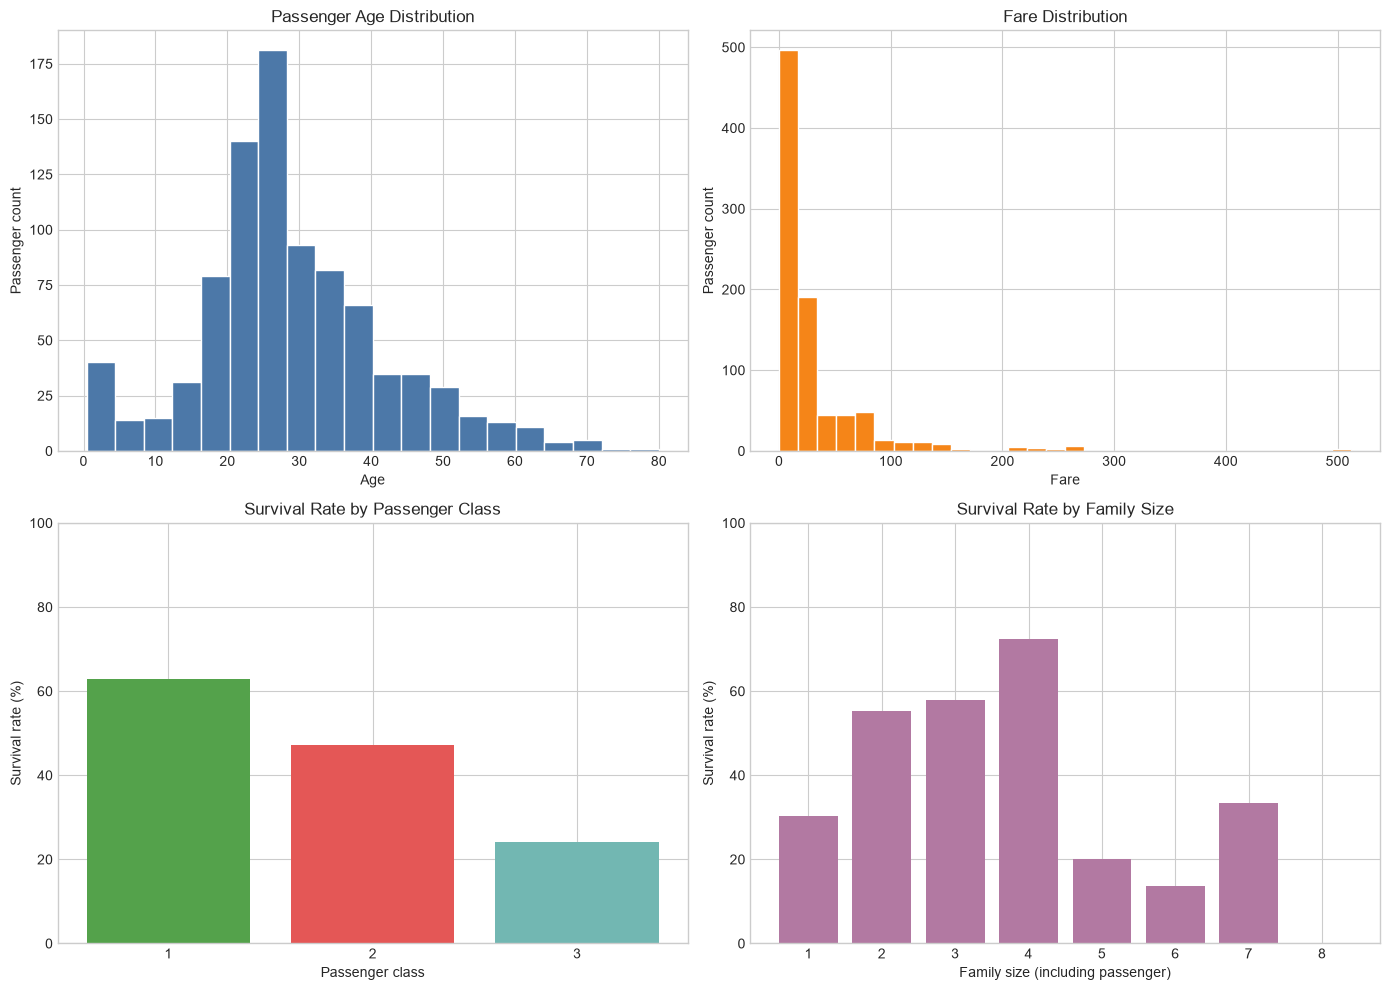

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['Age'], bins=20, color='#4C78A8', edgecolor='white')
axes[0, 0].set_title('Passenger Age Distribution')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Passenger count')

axes[0, 1].hist(df['Fare'], bins=30, color='#F58518', edgecolor='white')
axes[0, 1].set_title('Fare Distribution')
axes[0, 1].set_xlabel('Fare')
axes[0, 1].set_ylabel('Passenger count')

class_rates = df.groupby('Pclass')['Survived'].mean().mul(100)
axes[1, 0].bar(class_rates.index.astype(str), class_rates.values, color=['#54A24B', '#E45756', '#72B7B2'])
axes[1, 0].set_title('Survival Rate by Passenger Class')
axes[1, 0].set_xlabel('Passenger class')
axes[1, 0].set_ylabel('Survival rate (%)')
axes[1, 0].set_ylim(0, 100)

family_rates = df.groupby('FamilySize')['Survived'].mean().mul(100).head(8)
axes[1, 1].bar(family_rates.index.astype(str), family_rates.values, color='#B279A2')
axes[1, 1].set_title('Survival Rate by Family Size')
axes[1, 1].set_xlabel('Family size (including passenger)')
axes[1, 1].set_ylabel('Survival rate (%)')
axes[1, 1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

## 6. 남성과 여성의 생존율 비교

성별 생존율을 계산하고, 두 집단의 차이가 한눈에 보이도록 막대그래프로 출력합니다. 막대 위에는 정확한 비율을 표시합니다.

성별 생존율(%)


,생존율
Sex,
Male,18.89
Female,74.20


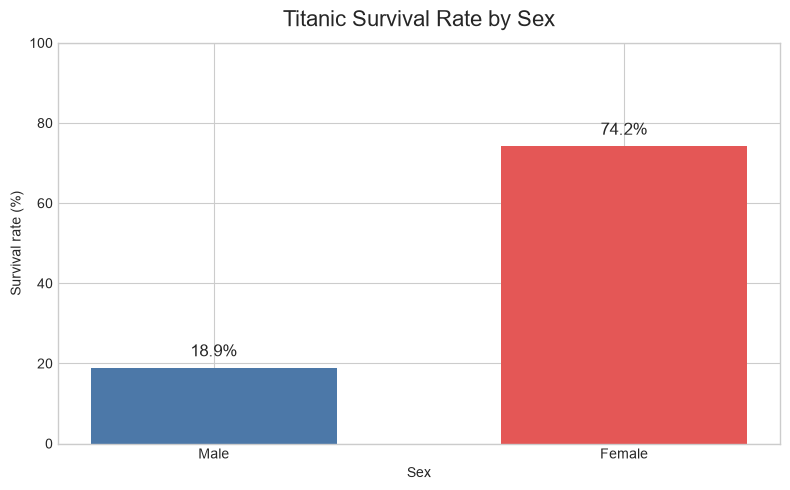

In [9]:
gender_labels = {'male': 'Male', 'female': 'Female'}
gender_survival = df.groupby('Sex', observed=True)['Survived'].mean().mul(100).rename(index=gender_labels)
gender_survival = gender_survival.reindex(['Male', 'Female'])

print('성별 생존율(%)')
display(gender_survival.round(2).to_frame('생존율'))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(gender_survival.index, gender_survival.values, color=['#4C78A8', '#E45756'], width=0.6)
ax.set_title('Titanic Survival Rate by Sex', fontsize=16, pad=12)
ax.set_xlabel('Sex')
ax.set_ylabel('Survival rate (%)')
ax.set_ylim(0, 100)
for bar, rate in zip(bars, gender_survival.values):
    ax.text(bar.get_x() + bar.get_width() / 2, rate + 2, f'{rate:.1f}%', ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

## 7. 분석 요약

- 타이타닉 데이터는 성별과 객실 등급에 따라 생존율 차이가 크게 나타납니다.
- 일반적으로 여성의 생존율이 남성보다 높고, 1등석 승객의 생존율이 3등석보다 높습니다.
- `Age`와 `Cabin`의 결측치는 분석에서 제외하지 않고 합리적인 대체값과 결측 여부 파생 변수로 처리했습니다.
- 관찰된 차이는 데이터의 연관성을 보여주며, 생존 원인에 대한 인과관계를 의미하지는 않습니다.